Lecture: AI I - Basics 

Previous:
[**Chapter 3.6: Additional Libraries and Tools**](../03_data/06_additionals.ipynb)

---

# Chapter 4.1: Data Preparation with scikit-learn

- [Imputation](#imputation)
- [Scaling](#scaling)
- [Dimensionality Reduction](#dimensionality-reduction)
- [Pipelines](#pipelines)
- [Feature Union](#feature-union)
- [Column Transformations](#column-transformations)

__Scikit-learn__ (also known as __sklearn__) is an open-source software library for machine learning in Python. It is very popular and actively maintained. The library offers various classification, regression, and clustering algorithms. In addition, sklearn also includes algorithms for model selection, dimensionality reduction, and data preprocessing.  

In this notebook, we (again) focus on data preprocessing (Data Preparation) and cover the following topics:
- Imputation  
- Scaling  
- Dimensionality Reduction  
- Pipelines  
- Feature Union  
- Column Transformations  

The documentation for scikit-learn can be found [here](https://scikit-learn.org/stable/index.html).  


In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns

## Imputation

Imputation refers to the completion of missing values (NaNs). As in pandas, there are various methods in sklearn to replace missing values. More information can be found [here](https://scikit-learn.org/stable/modules/impute.html).  


In [3]:
nan_data = np.array([[1, 2], [np.nan, 3], [7, 6]])

### One-dimensional Imputation

In one-dimensional imputation, the values are replaced column by column. The class [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html#sklearn.impute.SimpleImputer) provides basic strategies for this purpose. Missing values can be replaced with a given constant value or with statistical values (mean, median, or most frequent value) of each column containing the missing values. This class also allows for different encodings of missing values.  


In [4]:
from sklearn.impute import SimpleImputer

# define different imputer
mean_imputer = SimpleImputer()
zero_imputer = SimpleImputer(strategy='constant', fill_value=0)

In [5]:
# First the imputer has to be fitted to the data, so either call first fit and then transform 
# or call fit_transform to do it in one step
mean_imputer.fit(nan_data)
mean_imputer.transform(nan_data)

array([[1., 2.],
       [4., 3.],
       [7., 6.]])

In [6]:
zero_imputer.fit_transform(nan_data)

array([[1., 2.],
       [0., 3.],
       [7., 6.]])

In [7]:
different_nan_data = np.array([[np.nan, 5], [8, 2], [6, 6]])
mean_imputer.transform(different_nan_data)

array([[4., 5.],
       [8., 2.],
       [6., 6.]])

__Brainstorming:__  
<details>
<summary>Why was np.nan replaced with 4?</summary>
Because the mean_imputer was previously "trained" on the other data.  
</details>

<details>
<summary>When can this behavior be an advantage?</summary>
An advantage is that the imputation strategies or exact values used during training can also be applied at test time or in live operation.  
</details>


In [8]:
zero_imputer.transform(different_nan_data)

array([[0., 5.],
       [8., 2.],
       [6., 6.]])

It is also possible to replace values other than `np.nan`.  


In [9]:
fischers_fritz = [
    ['Fischers', '', 'fischt', 'frische', 'Fische'],
    ['Frische', 'Fische', 'fischt', 'Fischers', '']
]

string_imputer = SimpleImputer(missing_values='', strategy='constant', fill_value='Fritz')
string_imputer.fit_transform(fischers_fritz)          

array([['Fischers', 'Fritz', 'fischt', 'frische', 'Fische'],
       ['Frische', 'Fische', 'fischt', 'Fischers', 'Fritz']], dtype=object)

### Multidimensional Variant
The multidimensional variant is significantly more complex. Roughly summarized, each missing value is modeled as a function of other features, and this estimate is then used for imputation. This process is repeated several times before the final replacements are made. This behavior is implemented by the [IterativeImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html#sklearn.impute.IterativeImputer).  

> __Note:__ This class is still experimental.  


In [10]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401

from sklearn.impute import IterativeImputer

First, we create a small dummy dataset where the values of the individual columns have a clear relationship to each other.  


In [11]:
x = np.arange(1, 11, dtype="float")
y = x * x 

data = np.array([x, y])
data[(0, 1)] = np.nan
data[(0, 6)] = np.nan
data[(1, 3)] = np.nan
data[(1, 9)] = np.nan
data = data.T
data

array([[ 1.,  1.],
       [nan,  4.],
       [ 3.,  9.],
       [ 4., nan],
       [ 5., 25.],
       [ 6., 36.],
       [nan, 49.],
       [ 8., 64.],
       [ 9., 81.],
       [10., nan]])

Afterwards, we can again use `fit_transform` to replace the data.  


In [12]:
IterativeImputer().fit_transform(data)

array([[ 1.        ,  1.        ],
       [ 2.3175117 ,  4.        ],
       [ 3.        ,  9.        ],
       [ 4.        , 22.35578423],
       [ 5.        , 25.        ],
       [ 6.        , 36.        ],
       [ 6.58808359, 49.        ],
       [ 8.        , 64.        ],
       [ 9.        , 81.        ],
       [10.        , 83.09539114]])

The replacements of the `SimpleImputer`, on the other hand, look as follows.  


In [13]:
SimpleImputer().fit_transform(data)

array([[ 1.   ,  1.   ],
       [ 5.75 ,  4.   ],
       [ 3.   ,  9.   ],
       [ 4.   , 33.625],
       [ 5.   , 25.   ],
       [ 6.   , 36.   ],
       [ 5.75 , 49.   ],
       [ 8.   , 64.   ],
       [ 9.   , 81.   ],
       [10.   , 33.625]])

__Brainstorming:__  
<details>
    <summary>What are the advantages of the multidimensional variant?</summary>
    A major advantage is that the missing data is replaced depending on other data. This is often better, as there may be dependencies between the data. Example: height and weight of individuals.
</details>


In the following three lines of code, the iterative working method of the algorithm becomes visible.  


In [14]:
IterativeImputer(max_iter=1).fit_transform(data)

/workspaces/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


array([[ 1.        ,  1.        ],
       [ 3.10315829,  4.        ],
       [ 3.        ,  9.        ],
       [ 4.        , 20.73213454],
       [ 5.        , 25.        ],
       [ 6.        , 36.        ],
       [ 6.8956479 , 49.        ],
       [ 8.        , 64.        ],
       [ 9.        , 81.        ],
       [10.        , 82.62527756]])

In [15]:
IterativeImputer(max_iter=2).fit_transform(data)

/workspaces/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


array([[ 1.        ,  1.        ],
       [ 2.34645245,  4.        ],
       [ 3.        ,  9.        ],
       [ 4.        , 22.28201783],
       [ 5.        , 25.        ],
       [ 6.        , 36.        ],
       [ 6.61040064, 49.        ],
       [ 8.        , 64.        ],
       [ 9.        , 81.        ],
       [10.        , 83.06934333]])

In [16]:
IterativeImputer(max_iter=3).fit_transform(data)

array([[ 1.        ,  1.        ],
       [ 2.3175117 ,  4.        ],
       [ 3.        ,  9.        ],
       [ 4.        , 22.35578423],
       [ 5.        , 25.        ],
       [ 6.        , 36.        ],
       [ 6.58808359, 49.        ],
       [ 8.        , 64.        ],
       [ 9.        , 81.        ],
       [10.        , 83.09539114]])

## Scaling

### Standardization
Standardization refers to a transformation of the input data such that the resulting data has a mean of 0 and a variance of 1. The resulting data is therefore normally distributed. This is particularly helpful when all variables are scaled differently.  

__Example:__ A dataset contains the values height in meters and weight in kilograms of people. The variance of the variables will clearly differ, since height is on a scale from 0.1 m to 2.8 m, while weight is on a scale from 0.5 kg to 600 kg.  

In sklearn, the class [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) is used for standardization.  


In [17]:
from sklearn.preprocessing import StandardScaler

scaling_data = np.array([
    [1.79, 79.5], 
    [1.60, 53.2], 
    [2.59, 150], 
    [1.73, 70.7], 
    [1.50, 46.7], 
    [1.75, 113.0], 
    [1.93, 247.2]
])
print(f"Mittelwerte pro Feature: {scaling_data.mean(axis=0)}")
print(f"Standardabweichung pro Feature: {scaling_data.std(axis=0)}")

Mittelwerte pro Feature: [  1.84142857 108.61428571]
Standardabweichung pro Feature: [ 0.33090476 65.60408151]


In [18]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(scaling_data)
scaled_data

array([[-0.15541805, -0.44378772],
       [-0.72960139, -0.84467741],
       [ 2.26219602,  0.63084054],
       [-0.3367391 , -0.57792572],
       [-1.03180315, -0.94375661],
       [-0.27629875,  0.06685124],
       [ 0.26766441,  2.11245568]])

In [19]:
print(f"Mittelwerte pro Feature: {scaled_data.mean(axis=0)}")
print(f"Standardabweichung pro Feature: {scaled_data.std(axis=0)}")

Mittelwerte pro Feature: [-3.17206578e-17  6.34413157e-17]
Standardabweichung pro Feature: [1. 1.]


__Brainstorming:__  
<details>
<summary>Why isn’t the mean at 0?</summary>
These are calculation errors that can be neglected. e-17 is an extremely small number.
</details>


If the data should not be centered, this can be prevented with the parameter `with_mean=False`.  


In [20]:
not_center_scaler = StandardScaler(with_mean=False)
non_centric_data = not_center_scaler.fit_transform(scaling_data)

print(f"Mittelwerte pro Feature: {non_centric_data.mean(axis=0)}")
print(f"Standardabweichung pro Feature: {non_centric_data.std(axis=0)}")
non_centric_data

Mittelwerte pro Feature: [5.56482953 1.65560257]
Standardabweichung pro Feature: [1. 1.]


array([[5.40941148, 1.21181485],
       [4.83522814, 0.81092516],
       [7.82702555, 2.28644311],
       [5.22809043, 1.07767685],
       [4.53302638, 0.71184595],
       [5.28853078, 1.72245381],
       [5.83249394, 3.76805824]])

It is also possible not to scale the data in order to preserve the variance. For this, the constructor must be called with the parameter `with_std=False`.  


In [21]:
not_scaling_scaler = StandardScaler(with_std=False)
non_scaled_data = not_scaling_scaler.fit_transform(scaling_data)

print(f"Mittelwerte pro Feature: {non_scaled_data.mean(axis=0)}")
print(f"Standardabweichung pro Feature: {non_scaled_data.std(axis=0)}")
non_scaled_data

Mittelwerte pro Feature: [0. 0.]
Standardabweichung pro Feature: [ 0.33090476 65.60408151]


array([[-5.14285714e-02, -2.91142857e+01],
       [-2.41428571e-01, -5.54142857e+01],
       [ 7.48571429e-01,  4.13857143e+01],
       [-1.11428571e-01, -3.79142857e+01],
       [-3.41428571e-01, -6.19142857e+01],
       [-9.14285714e-02,  4.38571429e+00],
       [ 8.85714286e-02,  1.38585714e+02]])

### Scaling features to a specific range

Alternatively, features can be scaled so that they lie between a given minimum and maximum value, often between zero and one, or such that the maximum absolute value of each feature is scaled to unit size. This can be achieved with [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#) or [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html#).  


In [22]:
from sklearn.preprocessing import MinMaxScaler
min_max_data = np.array([
    [-1, 2], 
    [-0.5, 6], 
    [0, 10], 
    [1, 18]
])

zero_one_scaler = MinMaxScaler()
zero_one_scaler.fit_transform(min_max_data)

array([[0.  , 0.  ],
       [0.25, 0.25],
       [0.5 , 0.5 ],
       [1.  , 1.  ]])

To change the range, the parameter `feature_range` can be specified in the constructor.  


In [23]:
minus_one_one_scaler = MinMaxScaler(feature_range=(-1, 1))
minus_one_one_scaler.fit_transform(min_max_data)

array([[-1. , -1. ],
       [-0.5, -0.5],
       [ 0. ,  0. ],
       [ 1. ,  1. ]])

In [24]:
from sklearn.preprocessing import MaxAbsScaler
max_abs_data = np.array([
    [ 1., -1.,  2.],
    [ 2.,  0.,  0.],
    [ 0.,  1., -1.]
])

max_abs_scaler = MaxAbsScaler()
max_abs_scaler.fit_transform(max_abs_data)

array([[ 0.5, -1. ,  1. ],
       [ 1. ,  0. ,  0. ],
       [ 0. ,  1. , -0.5]])

### Problems with Outliers
The three previously introduced classes are not particularly good at handling outliers during scaling. This problem is illustrated [here](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py).  

A scaler that works with outliers is the [RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html).  


In [25]:
from sklearn.preprocessing import RobustScaler
outlier_data = np.array([
    [2, 4, 1, 27, 3, 4, 1, 3, 3, 2],
    [100, 92, 87, 94, 95, 83, 177, 84, 99, 89]
]).T

robust_scaler = RobustScaler(quantile_range=(25, 75))
robust_scaler.fit_transform(outlier_data)

array([[-0.57142857,  0.66666667],
       [ 0.57142857, -0.0952381 ],
       [-1.14285714, -0.57142857],
       [13.71428571,  0.0952381 ],
       [ 0.        ,  0.19047619],
       [ 0.57142857, -0.95238095],
       [-1.14285714,  8.        ],
       [ 0.        , -0.85714286],
       [ 0.        ,  0.57142857],
       [-0.57142857, -0.38095238]])

In [26]:
robust_scaler.scale_

array([ 1.75, 10.5 ])

In [27]:
robust_scaler.center_

array([ 3., 93.])

In comparison, the StandardScaler would scale the data as follows.  


In [28]:
StandardScaler().fit_transform(outlier_data)

array([[-0.40525742,  0.        ],
       [-0.13508581, -0.30477573],
       [-0.54034323, -0.49526056],
       [ 2.97188775, -0.2285818 ],
       [-0.27017161, -0.19048483],
       [-0.13508581, -0.64764842],
       [-0.54034323,  2.93346637],
       [-0.27017161, -0.60955145],
       [-0.27017161, -0.03809697],
       [-0.40525742, -0.41906662]])

__Exercise:__  
<details>
<summary>How are the new values calculated?</summary>
First, the median and the quantiles per column must be determined. Then the new values can be calculated as follows:  

$$x_{new} = \frac{x_{old} - median}{quantile_{upper} - quantile_{lower}}$$
</details>


## Dimensionality Reduction
Dimensionality reduction refers to the reduction of the number of random variables. This can be helpful both for visualization and for machine learning.  

In the following, we will use the Iris dataset (Iris = sword lily). It consists of 4 features (sepal length, sepal width, petal length, and petal width) and has 3 classes.  


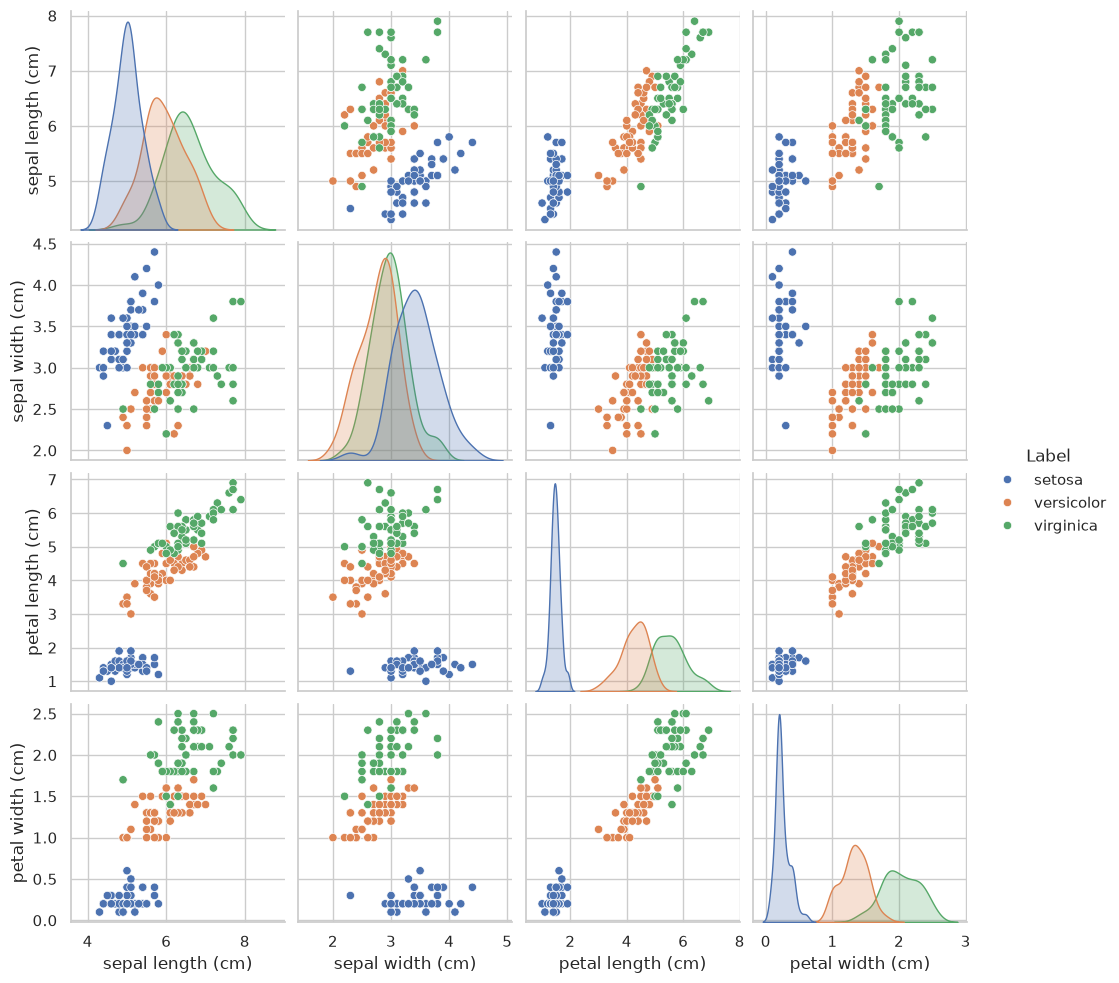

In [29]:
iris = datasets.load_iris(as_frame=True)
iris_df = iris.frame
iris_df['Label'] = iris.target_names[iris_df['target']]
iris_df = iris_df.drop('target', axis=1)

sns.set_theme(style="whitegrid")
sns.pairplot(iris_df, hue="Label")

### Principal Component Analysis (PCA)

PCA is used to decompose a multidimensional dataset into a set of successive orthogonal components that explain the maximum proportion of variance. Like the previous algorithms, [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) is implemented as a transformer object. This means it must first be trained with `fit()`. Afterwards, it can be applied to the data to find the $n$ features that explain the largest proportion of variance in the data.  


Text(0, 0.5, 'Dimension 2')

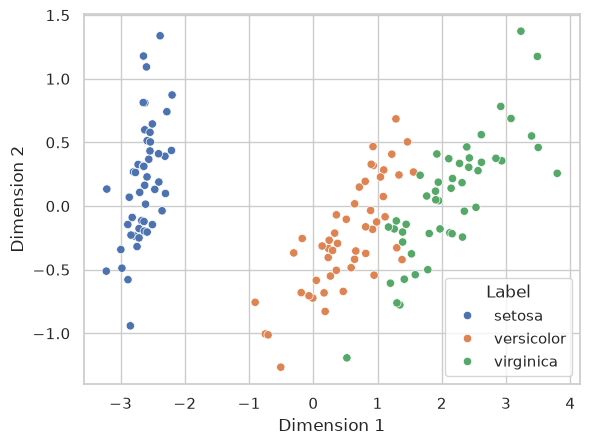

In [30]:
from sklearn.decomposition import PCA

# we want to have the two components with the highest variance
pca = PCA(n_components=2)
pca.fit(iris.data)
reduced_iris = pca.transform(iris.data)

# show the two components with the highest variance
ax_pca = sns.scatterplot(x=reduced_iris[:, 0], y=reduced_iris[:, 1], hue=iris_df['Label'])
ax_pca.set_xlabel('Dimension 1')
ax_pca.set_ylabel('Dimension 2')

__Brainstorming:__  
<details>
<summary>What could be a weakness of PCA in the context of a classification task?</summary>
PCA tries to find the greatest variance in the entirety of the data. However, PCA does not take into account the variance between the individual classes. This can lead to suboptimal features being selected for classification.  
</details>


### Linear Discriminant Analysis (LDA)

[Linear Discriminant Analysis (LDA)]() uses class membership in contrast to PCA. It attempts to determine the features that have the greatest influence on the variance between the classes. Since LDA makes use of class membership, it is a supervised method.  


Text(0, 0.5, 'Dimension 2')

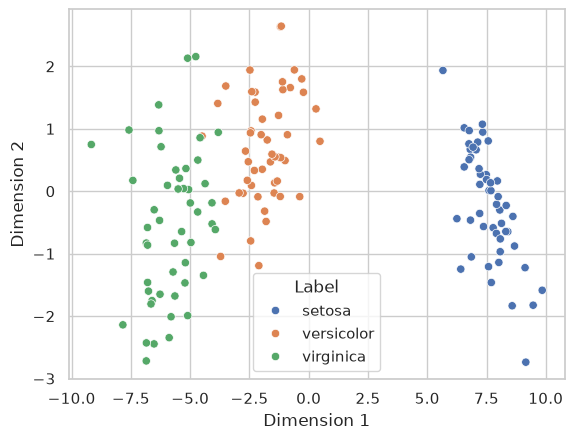

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(iris.data, iris.target)
lda_reduced_iris = lda.transform(iris.data)

# show the two components with the highest variance between classes
ax_lda = sns.scatterplot(x=lda_reduced_iris[:, 0], y=lda_reduced_iris[:, 1], hue=iris_df['Label'])
ax_lda.set_xlabel('Dimension 1')
ax_lda.set_ylabel('Dimension 2')

### Comparison of PCA and LDA


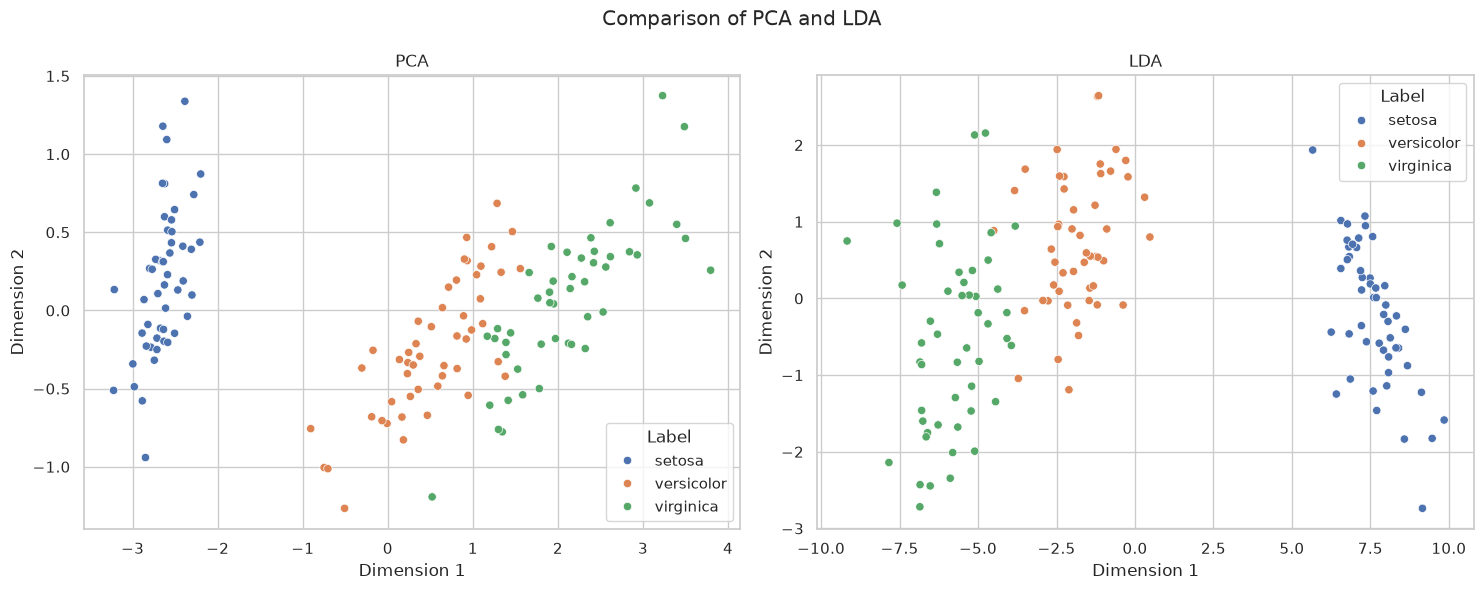

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(x=reduced_iris[:, 0], y=reduced_iris[:, 1], hue=iris_df['Label'], ax=ax1)
ax1.set_xlabel('Dimension 1')
ax1.set_ylabel('Dimension 2')
ax1.set_title('PCA')

sns.scatterplot(x=lda_reduced_iris[:, 0], y=lda_reduced_iris[:, 1], hue=iris_df['Label'], ax=ax2)
ax2.set_xlabel('Dimension 1')
ax2.set_ylabel('Dimension 2')
ax2.set_title('LDA')

fig.suptitle('Comparison of PCA and LDA')
fig.tight_layout()

## Pipelines
[Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) can be used to chain multiple estimators into one. This is useful because there is often a fixed sequence of steps in data processing, such as feature selection, normalization, and classification. Pipelines serve several purposes here:

1) __Convenience and encapsulation__  
> You only need to call `fit` and `predict` once on your data to fit an entire sequence of estimators.

2) __Joint parameter selection__  
> You can perform a grid search over the parameters of all estimators in the pipeline at once. We will cover this in more detail later.

3) __Safety__  
> Pipelines help prevent statistics from leaking from your test data into the trained model during cross-validation (we will also cover this later) by ensuring that the same samples are used to train the transformers and predictors.

All estimators in a pipeline, except the last one, must be transformers (i.e., they must have a `transform` method). The last estimator can be of any type (transformer, classifier, etc.).  


### Constructor
The [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) is built with a list of (key, value) pairs, where the key is a string containing the name you want to assign to this step, and the value is an estimator.  


In [33]:
from sklearn.pipeline import Pipeline

# first, create a dictionary with all the estimators we want to have in the pipeline, each step needs a name
estimators = [('imputer', SimpleImputer()), ('scaler', StandardScaler())]

# then, pass the estimators to the Pipeline constructor
pipe = Pipeline(estimators)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for 

In [34]:
# if you don't want to name the estimators explicit you can use the make_pipeline function
from sklearn.pipeline import make_pipeline
make_pipeline(SimpleImputer(), StandardScaler())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatort

### Setting parameters of estimators
The parameters of the estimators in the pipeline can be accessed using the syntax `<estimator>__<parameter>` (_2 underscores_).  


In [35]:
pipe.set_params(imputer__strategy='constant', imputer__fill_value=0)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'constant'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",0
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for

After setting the parameters, we can test the pipeline with dummy values.  


In [36]:
pipe_data = [[1, 4], [5, 8], [np.nan, 5], [3, np.nan]]
pipe.fit_transform(pipe_data)

array([[-0.65094455, -0.08737041],
       [ 1.43207802,  1.31055608],
       [-1.1717002 ,  0.26211122],
       [ 0.39056673, -1.4852969 ]])

To use different parameters, they must again be set with `set_params()`.  


In [37]:
# reset to default parameters
pipe.set_params(imputer__strategy='mean', imputer__fill_value=None)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indic

In [38]:
pipe.fit_transform(pipe_data)

array([[-1.41421356, -1.13227703],
       [ 1.41421356,  1.58518785],
       [ 0.        , -0.45291081],
       [ 0.        ,  0.        ]])

It is also possible to completely replace individual steps. For this, `set_params()` is also used, specifying the name of the step that should be replaced.  


In [39]:
pipe.set_params(scaler=MaxAbsScaler())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for 

In [40]:
pipe.fit_transform(pipe_data)

array([[0.2       , 0.5       ],
       [1.        , 1.        ],
       [0.6       , 0.625     ],
       [0.6       , 0.70833333]])

If a step in the pipeline should no longer be executed, this can be achieved by passing the value `'passthrough'`.  


In [41]:
pipe.set_params(imputer='passthrough')

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueSet to False to perform inplace scaling and avoid a copy (if the inputis already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data to [-1, 1].Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the [-1, 1] range, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data.",False
Name,Type,Value
"max_abs_ max_abs_: ndarray of shape (n_features,)Per feature maximum absolute value.","ndarray[float64](2,)","[5.,8.]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator. Will be reset onnew calls to fit, but increments across ``partial_fit`` calls.",int,4
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data... versionadded:: 0.17 *scale_* attribute.","ndarray[float64](2,)","[5.,8.]"


In [42]:
pipe.fit_transform(pipe_data)

array([[0.2  , 0.5  ],
       [1.   , 1.   ],
       [  nan, 0.625],
       [0.6  ,   nan]])

## Feature Union
[FeatureUnion](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.FeatureUnion.html) combines multiple transformer objects into a new transformer that merges their outputs. A FeatureUnion takes a list of transformer objects. During fitting, each of them is independently fitted to the data. The transformers are applied in parallel, and the feature matrices they output are concatenated side by side into a larger matrix.  


### Constructor
A FeatureUnion is built from a list of (key, value) pairs, where the key is the name you want to assign to a given transformation and the value is an estimator.  


In [43]:
from sklearn.pipeline import FeatureUnion
from sklearn.decomposition import KernelPCA

estimators = [('linear_pca', PCA()), ('kernel_pca', KernelPCA())]
combined = FeatureUnion(estimators)
combined

,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('linear_pca', ...), ('kernel_pca', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_featur

Here as well, it is possible not to explicitly name the steps. For this, the method `make_union()` can be used.  


In [44]:
from sklearn.pipeline import make_union
make_union(PCA(), KernelPCA())

,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('pca', ...), ('kernelpca', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It i

In [45]:
combined_data = [[1, 4, 3], [5, 8, 7], [2, 5, 4], [3, 6, 5]]
combined.fit_transform(combined_data)

array([[-3.03108891e+00,  3.02620036e-16, -0.00000000e+00,
        -3.03108891e+00],
       [ 3.89711432e+00,  2.17973424e-16,  0.00000000e+00,
         3.89711432e+00],
       [-1.29903811e+00, -4.24413644e-17,  0.00000000e+00,
        -1.29903811e+00],
       [ 4.33012702e-01,  2.92553432e-17,  0.00000000e+00,
         4.33012702e-01]])

### Setting transformer parameters
Here too, the parameters of the transformers can be set using the `set_params()` method.  


In [46]:
combined.set_params(linear_pca__n_components=3)

,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('linear_pca', ...), ('kernel_pca', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first transformer in `transformer_list` exposes such anattribute when fit... versionadded:: 0.24,int,3
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on ce

To ignore a step, the value `'drop'` must be assigned to the corresponding step name.  


In [47]:
combined.set_params(kernel_pca='drop')

,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('linear_pca', ...), ('kernel_pca', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first transformer in `transformer_list` exposes such anattribute when fit... versionadded:: 0.24,int,3
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on ce

## Column Transformations
Many datasets contain features of different types, e.g., text, floating-point numbers, and dates, where each feature type requires separate preprocessing or feature extraction steps. Often, it is easiest to preprocess the data before applying scikit-learn methods, for example with __Pandas__.  

However, preprocessing the data before passing it to scikit-learn can be problematic for one of the following reasons:  
1) Including statistics from test data in the preprocessors makes cross-validation results unreliable (known as data leakage), for example in the case of scalers or imputation of missing values.  

2) You may want to include preprocessing parameters in a parameter search.  

The [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) helps perform different transformations for different columns of the data, within a pipeline that is safe from data leakage and can be parameterized.  

### Creating dummy data
First, we create a dataset that contains both numeric data and text.  


In [48]:
book_data_raw = pd.DataFrame(
    {
        'city': ['London', 'London', 'Paris', 'Sallisaw'],
        'title': ["His Last Bow", "How Watson Learned the Trick", "A Moveable Feast", "The Grapes of Wrath"],
        'expert_rating': [5, 3, 4, 5],
        'user_rating': [4, 5, 4, 3]
    }
)

__Brainstorming:__  

<details>
<summary>How can we use the text data?</summary>
To use text data for machine learning, it must be converted into numbers. In this case, the city can, for example, be one-hot encoded, and for the title we can count the occurring words (we will go into more detail on this in the seminar).
</details>


### Constructor
We want to apply the [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder) to the `'city'` column and the [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html#sklearn.feature_extraction.text.CountVectorizer) to the `'title'` column.  


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder

column_trans = ColumnTransformer([
    ('city_category', OneHotEncoder(dtype='int'), ['city']),
    ('title_bow', CountVectorizer(), 'title')
])

column_trans.fit(book_data_raw) 

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('city_category', ...), ('title_bow', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and 

The names of the features can be obtained using the `get_feature_names()` method.  


In [50]:
column_trans.get_feature_names_out()

array(['city_category__city_London', 'city_category__city_Paris',
       'city_category__city_Sallisaw', 'title_bow__bow',
       'title_bow__feast', 'title_bow__grapes', 'title_bow__his',
       'title_bow__how', 'title_bow__last', 'title_bow__learned',
       'title_bow__moveable', 'title_bow__of', 'title_bow__the',
       'title_bow__trick', 'title_bow__watson', 'title_bow__wrath'],
      dtype=object)

In [51]:
column_trans.transform(book_data_raw).toarray()

array([[1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0],
       [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1]])

All features that were not passed to a transformer are, by default, not included in the output. To change this behavior, a value for the parameter `remainder` can be passed to the constructor.  


In [52]:
column_trans = ColumnTransformer([
    ('city_category', OneHotEncoder(dtype='int'), ['city']),
    ('title_bow', CountVectorizer(), 'title')
], remainder='passthrough')

column_trans.fit(book_data_raw)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('city_category', ...), ('title_bow', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name

In [53]:
column_trans.get_feature_names_out()

array(['city_category__city_London', 'city_category__city_Paris',
       'city_category__city_Sallisaw', 'title_bow__bow',
       'title_bow__feast', 'title_bow__grapes', 'title_bow__his',
       'title_bow__how', 'title_bow__last', 'title_bow__learned',
       'title_bow__moveable', 'title_bow__of', 'title_bow__the',
       'title_bow__trick', 'title_bow__watson', 'title_bow__wrath',
       'remainder__expert_rating', 'remainder__user_rating'], dtype=object)

In [54]:
column_trans.transform(book_data_raw)

array([[1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 5, 4],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 3, 5],
       [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 4, 4],
       [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 5, 3]])

Here too, there is the option not to explicitly assign names to the individual steps. For this, the method `make_column_transformer()` can be used. In addition, you can also pass a transformer to the `remainder` parameter. This transformer will then be applied to all remaining columns.  


In [55]:
from sklearn.compose import make_column_transformer
column_trans = make_column_transformer(
    (OneHotEncoder(), ['city']),
    (CountVectorizer(), 'title'),
    remainder=MinMaxScaler()
)
column_trans

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('countvectorizer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",MinMaxScaler()
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transform

In [56]:
column_trans.fit_transform(book_data_raw)

array([[1. , 0. , 0. , 1. , 0. , 0. , 1. , 0. , 1. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 1. , 0.5],
       [1. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 1. , 0. , 0. , 1. ,
        1. , 1. , 0. , 0. , 1. ],
       [0. , 1. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. ,
        0. , 0. , 0. , 0.5, 0.5],
       [0. , 0. , 1. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 1. , 1. ,
        0. , 0. , 1. , 1. , 0. ]])

## General Functionality
As you have probably already noticed, the steps are always the same:  

1. __Constructor:__ Create the algorithm. Most algorithms can be parameterized in this step.  
2. __fit():__ Train the algorithm on the provided data.  
3. __transform():__ With the `transform()` method, the algorithm can then perform the transformations on the given values.  


---

Lecture: AI I - Basics 

Exercise: [**Exercise 4.1: Data Preparation**](../04_ml/exercises/01_data_preparation.ipynb)

Next: [**Chapter 4.2: Machine Learning with scikit-learn**](../04_ml/02_machine_learning.ipynb)